<a href="https://colab.research.google.com/github/haasinisalihundam-netizen/ML_PROJECT_Bankruptcy-Prediction-Using-Decision-Trees-and-Random-Forest-with-Precision-Recall-Analys/blob/main/Bankruptcy_ML_Colab_CompleteNew_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bankruptcy Prediction — Complete ML Workflow (Colab Ready)

**Models:** Decision Tree and Random Forest  
**Dataset:** UCI Taiwanese Bankruptcy Prediction (Dataset 572)  
**Target:** `Bankrupt?` (`0` = Non-Bankrupt, `1` = Bankrupt)

This notebook is the **machine-learning part of the project**. It can be shown independently of the web application.

Workflow: **Load data → EDA → 70/30 split → preprocessing → feature selection → model training → test evaluation → Precision–Recall analysis**.


## 1. Import libraries


In [7]:
import io
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import joblib
import sklearn
import warnings

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix,
    classification_report, precision_recall_curve
)

RANDOM_STATE = 42
TEST_SIZE = 0.30
TARGET = "Bankrupt?"

# Some original UCI labels contain a CJK character not present in Matplotlib's
# default font. We clean plot labels below and silence only that harmless font warning.
warnings.filterwarnings("ignore", message=r"Glyph .* missing from font")

print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.6.1


## 2. Load the dataset — CSV or XLSX

In Google Colab, run this cell and choose the bankruptcy dataset file. The notebook accepts either `.csv` or `.xlsx` as long as the file has the same dataset schema and contains the target column `Bankrupt?`.


In [8]:
def load_bankruptcy_file():
    # Google Colab upload
    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise ValueError("No file uploaded.")
        filename = next(iter(uploaded))
        raw = uploaded[filename]
        suffix = Path(filename).suffix.lower()
        if suffix == ".csv":
            data = pd.read_csv(io.BytesIO(raw))
        elif suffix in {".xlsx", ".xls"}:
            data = pd.read_excel(io.BytesIO(raw))
        else:
            raise ValueError("Upload a CSV or XLSX file.")
        return data, filename
    except ImportError:
        # Local Jupyter fallback
        candidates = [Path("../dataset/data.csv"), Path("../dataset/data.xlsx"), Path("data.csv"), Path("data.xlsx")]
        path = next((p for p in candidates if p.exists()), None)
        if path is None:
            raise FileNotFoundError("Place data.csv or data.xlsx next to the notebook, or run in Google Colab.")
        data = pd.read_csv(path) if path.suffix.lower() == ".csv" else pd.read_excel(path)
        return data, str(path)

df, source_file = load_bankruptcy_file()
df.columns = df.columns.astype(str).str.strip()

if TARGET not in df.columns:
    raise ValueError(f"Required target column {TARGET!r} was not found.")

print("Loaded:", source_file)
print("Shape:", df.shape)
print("Financial features:", df.shape[1] - 1)
display(df.head())


Saving data.csv to data (1).csv
Loaded: data (1).csv
Shape: (6819, 96)
Financial features: 95


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the dataset **before modeling**. It is not the trained model itself.


In [9]:
print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Financial features:", df.shape[1] - 1)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

print()
print("Class counts:")
print(df[TARGET].value_counts().sort_index())

print()
print("Class percentages (%):")
print((df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2))


Rows: 6819
Columns: 96
Financial features: 95
Missing values: 0
Duplicate rows: 0

Class counts:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Class percentages (%):
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


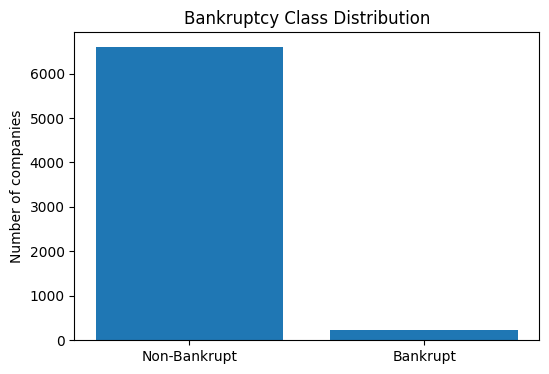

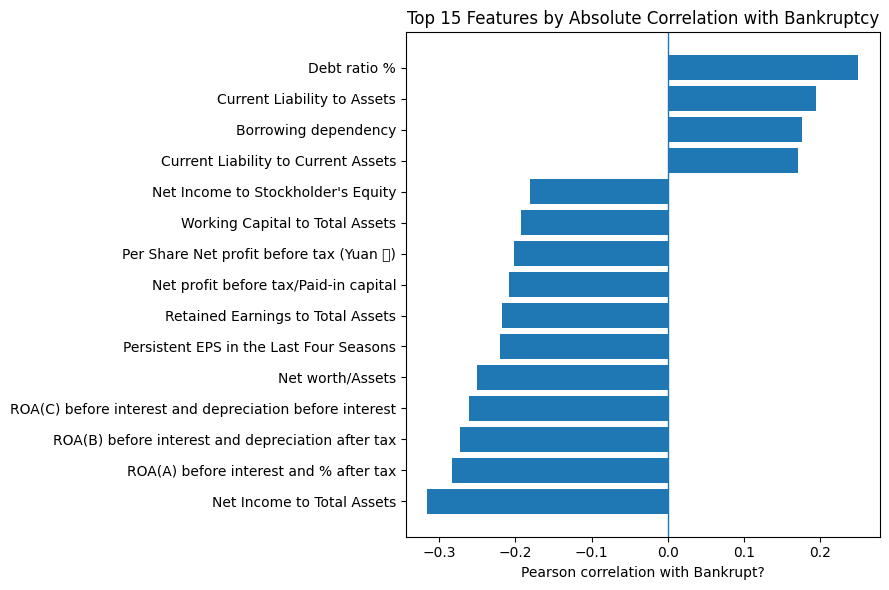

In [10]:
counts = df[TARGET].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["Non-Bankrupt", "Bankrupt"], [counts.get(0,0), counts.get(1,0)])
plt.title("Bankruptcy Class Distribution")
plt.ylabel("Number of companies")
plt.show()

# Correlation is undefined for constant columns. Remove them before calculation
# so this EDA cell runs without divide-by-zero warnings.
numeric = df.drop(columns=[TARGET]).select_dtypes(include=np.number)
numeric = numeric.loc[:, numeric.nunique(dropna=True) > 1]
y_all = pd.to_numeric(df[TARGET], errors="raise").astype(int)
corrs = numeric.corrwith(y_all).dropna()
top_corr = corrs.abs().sort_values(ascending=False).head(15)
plot_corr = pd.Series({f: corrs[f] for f in top_corr.index}).sort_values()

# A few original UCI column labels contain the character "樓", which the
# default Matplotlib font cannot render. Clean labels for plotting only;
# the dataframe column names themselves are not changed.
def clean_plot_label(label):
    return str(label).replace(" 樓", "").replace("樓", "").strip()

y_pos = np.arange(len(plot_corr))
plt.figure(figsize=(9,6))
plt.barh(y_pos, plot_corr.values)
plt.yticks(y_pos, [clean_plot_label(x) for x in plot_corr.index])
plt.axvline(0, linewidth=1)
plt.title("Top 15 Features by Absolute Correlation with Bankruptcy")
plt.xlabel("Pearson correlation with Bankrupt?")
plt.tight_layout()
plt.show()


## 4. Separate features and target


In [11]:
X = df.drop(columns=[TARGET])
y = pd.to_numeric(df[TARGET], errors="raise").astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (6819, 95)
y shape: (6819,)


## 5. Make the 70% train / 30% test split **before preprocessing or feature selection**

The `stratify=y` argument preserves the rare bankrupt-class proportion in both partitions. The test partition remains untouched until final evaluation.


In [12]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train_raw))
print("Test rows:", len(X_test_raw))

print()
print("Train class counts:", y_train.value_counts().sort_index().to_dict())
print("Test class counts :", y_test.value_counts().sort_index().to_dict())


Training rows: 4773
Test rows: 2046

Train class counts: {0: 4619, 1: 154}
Test class counts : {0: 1980, 1: 66}


## 6. Preprocess using training data only

Median imputation is fitted on `X_train_raw` and only **transformed** on `X_test_raw`.


In [13]:
imputer_all = SimpleImputer(strategy="median")
X_train_all = pd.DataFrame(
    imputer_all.fit_transform(X_train_raw),
    columns=X.columns,
    index=X_train_raw.index
)
X_test_all = pd.DataFrame(
    imputer_all.transform(X_test_raw),
    columns=X.columns,
    index=X_test_raw.index
)

print("Training data after preprocessing:", X_train_all.shape)
print("Test data after preprocessing:", X_test_all.shape)


Training data after preprocessing: (4773, 95)
Test data after preprocessing: (2046, 95)


## 7. Feature selection on the 70% training partition only

A Random Forest is fitted using all 95 training features. The 10 highest training-only feature importances are selected for the final models.


,Feature,Importance
0,Total debt/Total net worth,0.047859
1,Borrowing dependency,0.046414
2,Persistent EPS in the Last Four Seasons,0.042484
3,Debt ratio %,0.039536
4,Continuous interest rate (after tax),0.039090
5,Retained Earnings to Total Assets,0.035629
6,Net worth/Assets,0.034979
7,Equity to Liability,0.034371
8,Liability to Equity,0.033415
9,Net Income to Total Assets,0.031252


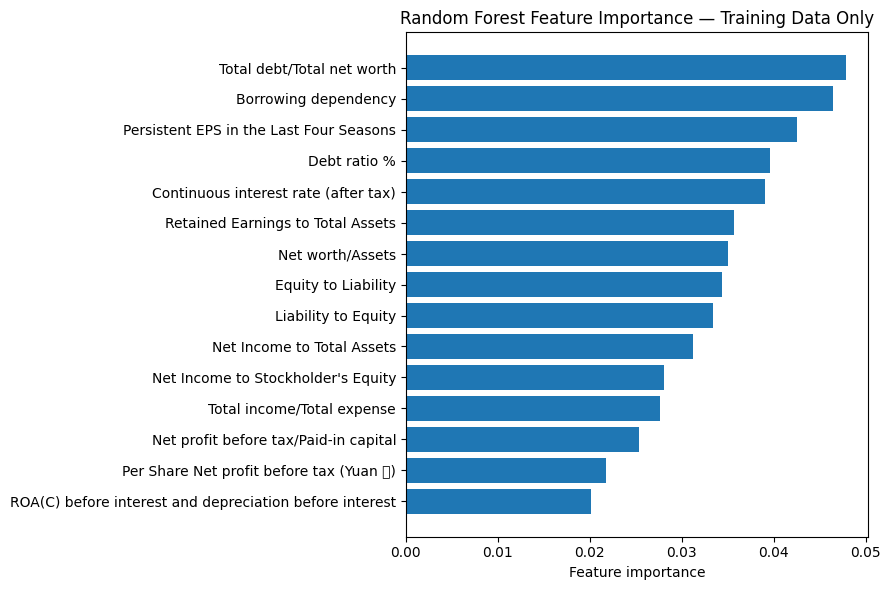

In [14]:
selector = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_depth=10,
    n_jobs=-1
)
selector.fit(X_train_all, y_train)

feature_importance = pd.Series(
    selector.feature_importances_, index=X.columns
).sort_values(ascending=False)

selected_features = feature_importance.head(10).index.tolist()
selected_table = pd.DataFrame({
    "Feature": selected_features,
    "Importance": feature_importance.loc[selected_features].values
})

display(selected_table)

fi_plot = feature_importance.head(15).sort_values()
y_pos = np.arange(len(fi_plot))
plt.figure(figsize=(9,6))
plt.barh(y_pos, fi_plot.values)
plt.yticks(y_pos, [clean_plot_label(x) for x in fi_plot.index])
plt.title("Random Forest Feature Importance — Training Data Only")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()


## 8. Prepare the selected 10 features


In [15]:
selected_imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(
    selected_imputer.fit_transform(X_train_raw[selected_features]),
    columns=selected_features,
    index=X_train_raw.index
)
X_test = pd.DataFrame(
    selected_imputer.transform(X_test_raw[selected_features]),
    columns=selected_features,
    index=X_test_raw.index
)

print("Final training matrix:", X_train.shape)
print("Final test matrix:", X_test.shape)


Final training matrix: (4773, 10)
Final test matrix: (2046, 10)


## 9. Train the two ML models


In [16]:
decision_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_depth=8
)

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_depth=10,
    n_jobs=-1
)

decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

print("Decision Tree trained.")
print("Random Forest trained.")


Decision Tree trained.
Random Forest trained.


## 10. Predict on the untouched 30% test set


In [17]:
dt_pred = decision_tree.predict(X_test)
rf_pred = random_forest.predict(X_test)

dt_proba = decision_tree.predict_proba(X_test)[:, 1]
rf_proba = random_forest.predict_proba(X_test)[:, 1]

print("Predictions generated for", len(y_test), "unseen test rows.")


Predictions generated for 2046 unseen test rows.


## 11. Evaluate Decision Tree and Random Forest


In [18]:
def evaluate_model(name, y_true, pred, proba):
    metrics = {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "Average Precision": average_precision_score(y_true, proba),
        "ROC-AUC": roc_auc_score(y_true, proba),
    }

    print()
    print(name)
    for key, value in metrics.items():
        print(f"{key:18s}: {value:.4f}")

    print("Confusion matrix:")
    print(confusion_matrix(y_true, pred))

    print()
    print("Classification report:")
    print(classification_report(y_true, pred, zero_division=0))
    return metrics

dt_metrics = evaluate_model("Decision Tree", y_test, dt_pred, dt_proba)
rf_metrics = evaluate_model("Random Forest", y_test, rf_pred, rf_proba)

comparison = pd.DataFrame(
    [dt_metrics, rf_metrics],
    index=["Decision Tree", "Random Forest"]
)
display(comparison.style.format("{:.4f}"))



Decision Tree
Accuracy          : 0.9159
Precision         : 0.2120
Recall            : 0.5909
F1                : 0.3120
Average Precision : 0.2373
ROC-AUC           : 0.7684
Confusion matrix:
[[1835  145]
 [  27   39]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1980
           1       0.21      0.59      0.31        66

    accuracy                           0.92      2046
   macro avg       0.60      0.76      0.63      2046
weighted avg       0.96      0.92      0.93      2046


Random Forest
Accuracy          : 0.9482
Precision         : 0.3148
Recall            : 0.5152
F1                : 0.3908
Average Precision : 0.3065
ROC-AUC           : 0.9042
Confusion matrix:
[[1906   74]
 [  32   34]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1980
           1       0.31      0.52      0.39        66

    accuracy     

,Accuracy,Precision,Recall,F1,Average Precision,ROC-AUC
Decision Tree,0.9159,0.2120,0.5909,0.3120,0.2373,0.7684
Random Forest,0.9482,0.3148,0.5152,0.3908,0.3065,0.9042


## 12. Confusion matrices


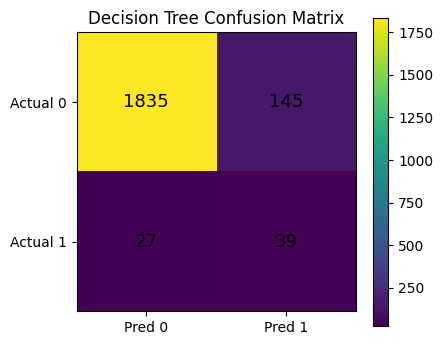

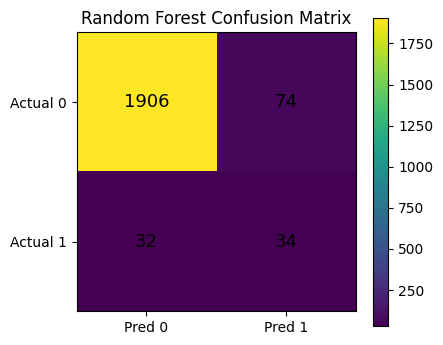

In [19]:
cms = {
    "Decision Tree": confusion_matrix(y_test, dt_pred),
    "Random Forest": confusion_matrix(y_test, rf_pred)
}

for name, cm in cms.items():
    plt.figure(figsize=(4.5,4))
    plt.imshow(cm)
    for i in range(2):
        for j in range(2):
            plt.text(j, i, int(cm[i,j]), ha="center", va="center", fontsize=13)
    plt.xticks([0,1], ["Pred 0", "Pred 1"])
    plt.yticks([0,1], ["Actual 0", "Actual 1"])
    plt.title(name + " Confusion Matrix")
    plt.colorbar()
    plt.show()


## 13. Precision–Recall analysis

The bankrupt class is rare, so Precision–Recall analysis is especially useful compared with accuracy alone.


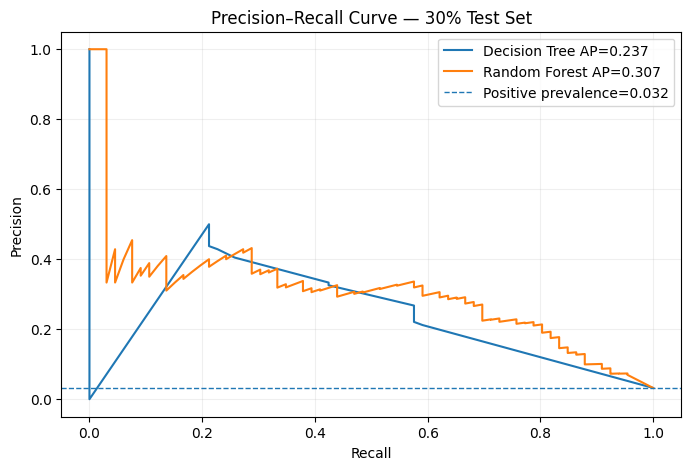

In [20]:
dt_precision, dt_recall, _ = precision_recall_curve(y_test, dt_proba)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(8,5))
plt.plot(dt_recall, dt_precision, label=f"Decision Tree AP={dt_metrics['Average Precision']:.3f}")
plt.plot(rf_recall, rf_precision, label=f"Random Forest AP={rf_metrics['Average Precision']:.3f}")
plt.axhline(y_test.mean(), linestyle="--", linewidth=1, label=f"Positive prevalence={y_test.mean():.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — 30% Test Set")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 14. Inspect the Decision Tree model itself

This is useful if you are asked to show the actual learned model rather than the web interface.


Decision Tree depth: 8
Decision Tree leaves: 67


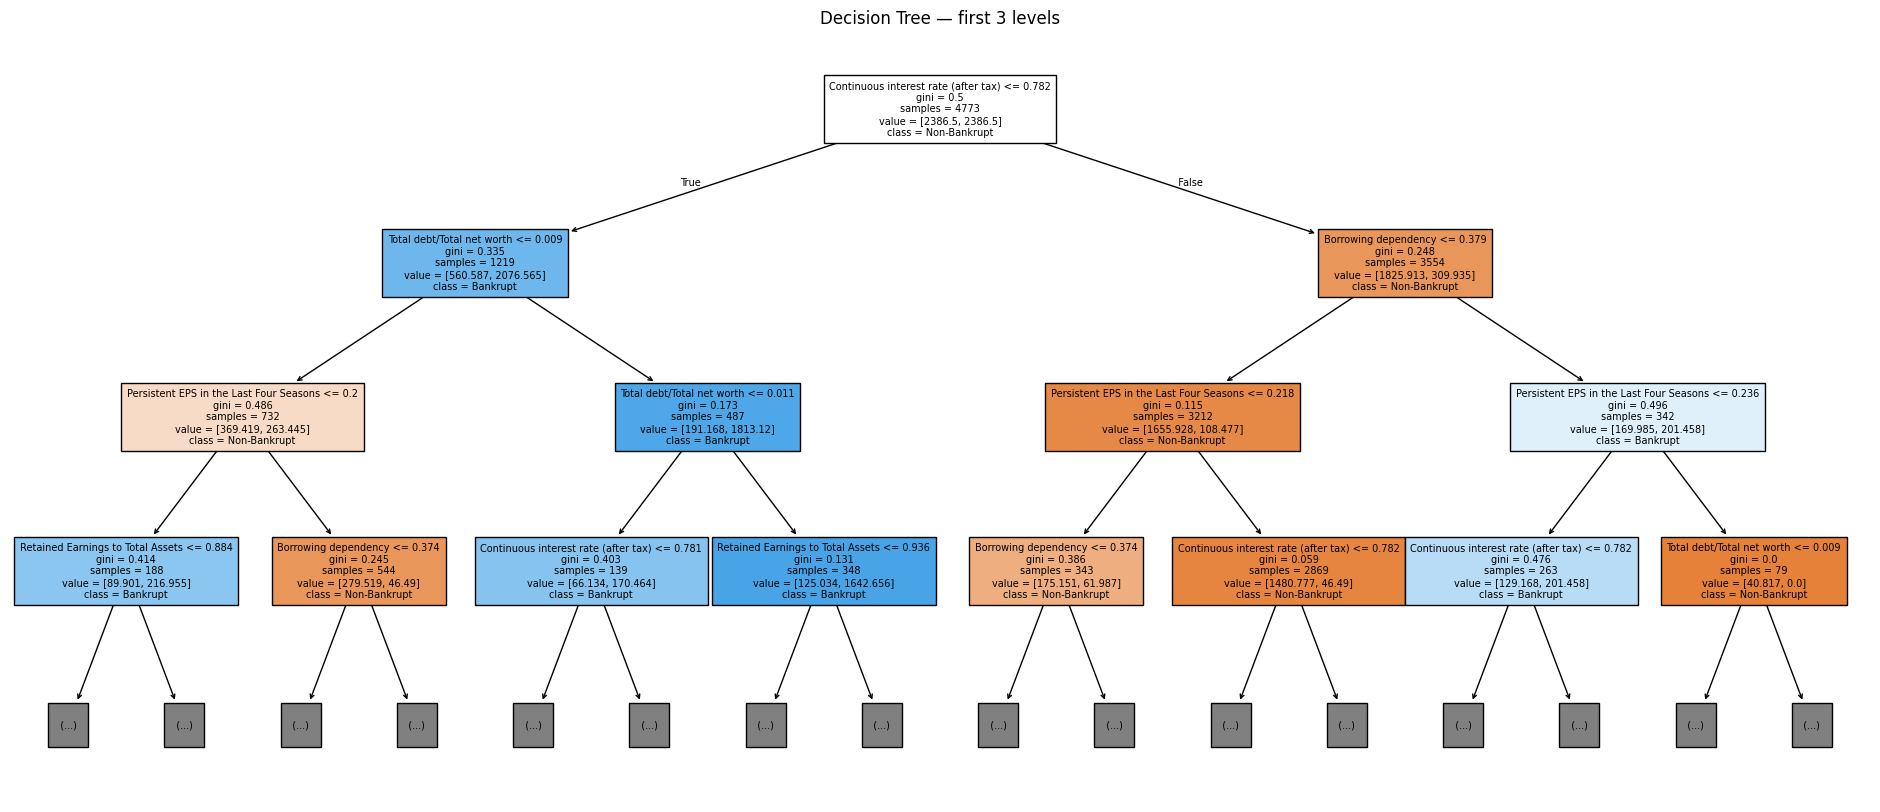

In [21]:
print("Decision Tree depth:", decision_tree.get_depth())
print("Decision Tree leaves:", decision_tree.get_n_leaves())

plt.figure(figsize=(24,10))
plot_tree(
    decision_tree,
    feature_names=selected_features,
    class_names=["Non-Bankrupt", "Bankrupt"],
    filled=True,
    max_depth=3,
    fontsize=7
)
plt.title("Decision Tree — first 3 levels")
plt.show()


## 15. Inspect Random Forest feature importance for the final 10-feature model


,Importance
Persistent EPS in the Last Four Seasons,0.162599
Continuous interest rate (after tax),0.153206
Retained Earnings to Total Assets,0.125947
Borrowing dependency,0.118531
Total debt/Total net worth,0.097516
Net Income to Total Assets,0.089488
Debt ratio %,0.073566
Equity to Liability,0.070062
Net worth/Assets,0.068891
Liability to Equity,0.040194


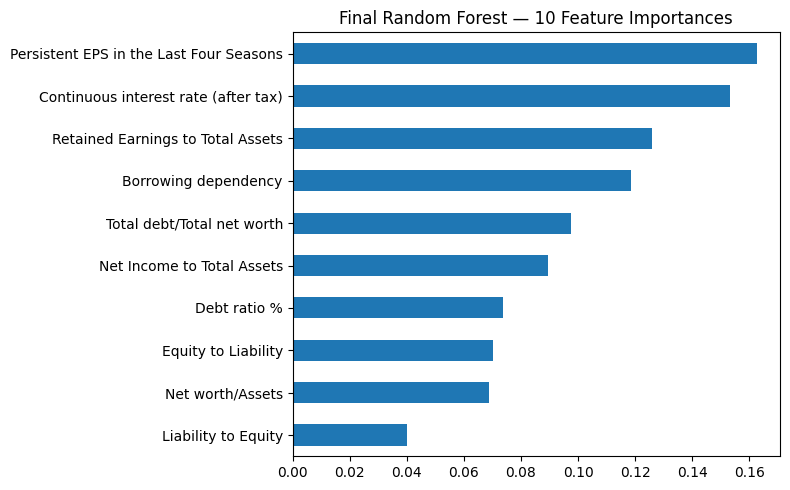

In [22]:
final_rf_importance = pd.Series(
    random_forest.feature_importances_, index=selected_features
).sort_values(ascending=False)

display(final_rf_importance.to_frame("Importance"))
final_rf_importance.sort_values().plot(kind="barh", figsize=(8,5), title="Final Random Forest — 10 Feature Importances")
plt.tight_layout()
plt.show()


## 16. Optional: run prediction on one held-out test row

This is **inference**, not retraining.


In [23]:
row_index = X_test.index[0]
sample = X_test.loc[[row_index]]
actual = int(y_test.loc[row_index])
rf_probability = float(random_forest.predict_proba(sample)[0,1])
rf_prediction = int(random_forest.predict(sample)[0])

print("Original dataset index:", row_index)
print("Actual class:", actual)
print("Predicted class:", rf_prediction)
print("Bankruptcy probability:", round(rf_probability * 100, 2), "%")
display(sample)


Original dataset index: 4893
Actual class: 0
Predicted class: 0
Bankruptcy probability: 0.0 %


,Total debt/Total net worth,Borrowing dependency,Persistent EPS in the Last Four Seasons,Debt ratio %,Continuous interest rate (after tax),Retained Earnings to Total Assets,Net worth/Assets,Equity to Liability,Liability to Equity,Net Income to Total Assets
4893,0.002456,0.369719,0.261133,0.062491,0.781787,0.950184,0.937509,0.061746,0.27656,0.833515


## 17. Export the trained ML artifacts

This cell saves the trained models, preprocessing object, selected-feature list and evaluation table so the trained pipeline can be reused without retraining.


In [24]:
EXPORT_DIR = Path("ml_exports")
EXPORT_DIR.mkdir(exist_ok=True)

joblib.dump(decision_tree, EXPORT_DIR / "decision_tree.pkl")
joblib.dump(random_forest, EXPORT_DIR / "random_forest.pkl")
joblib.dump(selected_imputer, EXPORT_DIR / "selected_imputer.pkl")
joblib.dump(selected_features, EXPORT_DIR / "selected_features.pkl")
(EXPORT_DIR / "selected_features.json").write_text(
    json.dumps(selected_features, indent=2), encoding="utf-8"
)
comparison.to_csv(EXPORT_DIR / "test_metrics.csv")

print("Saved trained artifacts to:", EXPORT_DIR.resolve())
print("Files:")
for path in sorted(EXPORT_DIR.iterdir()):
    print(" -", path.name)


Saved trained artifacts to: /content/ml_exports
Files:
 - decision_tree.pkl
 - random_forest.pkl
 - selected_features.json
 - selected_features.pkl
 - selected_imputer.pkl
 - test_metrics.csv


## What this notebook proves

- The raw dataset can be loaded from **CSV or XLSX**.
- EDA is performed before modeling.
- The dataset is split **70% training / 30% testing**.
- Preprocessing and feature selection are fitted on the **training partition only**.
- Decision Tree and Random Forest are actually trained with `.fit()`.
- The models are tested on unseen data with `.predict()` and `.predict_proba()`.
- Evaluation includes Precision, Recall, F1, Average Precision, ROC-AUC, confusion matrices and a Precision–Recall curve.

The web dashboard is a separate deployment/inference layer and is not required to demonstrate that the ML model was trained.
